In [1]:
# Import all the necessary modules
import os
import sys
import os, sys
# from .../research/notebooks -> go up two levels to repo root
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mtick
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
import pandas_datareader as pdr
import math
import glob
import datetime as dt
from datetime import datetime, timezone
import itertools
import ast
import yfinance as yf
import seaborn as sn
import yaml
import requests
from pathlib import Path
from IPython.display import display, HTML
from strategy_signal.trend_following_signal import (
    apply_jupyter_fullscreen_css, get_trend_donchian_signal_for_portfolio_with_rolling_r_sqr_vol_of_vol
)
from portfolio.strategy_performance import (calculate_sharpe_ratio, calculate_calmar_ratio, calculate_CAGR, calculate_risk_and_performance_metrics,
                                          calculate_compounded_cumulative_returns, estimate_fee_per_trade, rolling_sharpe_ratio)
from utils import coinbase_utils as cn
from portfolio import strategy_performance as perf
from sizing import position_sizing_binary_utils as size_bin
from sizing import position_sizing_continuous_utils as size_cont
from strategy_signal import trend_following_signal as tf
%matplotlib inline

In [2]:
import importlib
importlib.reload(cn)
importlib.reload(perf)
importlib.reload(tf)
importlib.reload(size_bin)
importlib.reload(size_cont)

<module 'sizing.position_sizing_continuous_utils' from '/Users/adheerchauhan/git/trend_following/sizing/position_sizing_continuous_utils.py'>

In [3]:
import warnings
warnings.filterwarnings('ignore')
pd.set_option('Display.max_rows', None)
pd.set_option('Display.max_columns',None)
apply_jupyter_fullscreen_css()

## Pull Data from Kraken Parquet Files

In [5]:
import os, glob
import pandas as pd

def list_parquets(folder: str) -> list[str]:
    return sorted(glob.glob(os.path.join(folder, "*.parquet")))

def load_parquets_long(folder: str) -> pd.DataFrame:
    """
    Long format: index=time, columns include [open,high,low,close,volume,trades, altname]
    """
    frames = []
    for fp in list_parquets(folder):
        if os.path.basename(fp) == "manifest.csv":
            continue
        df = pd.read_parquet(fp)
        df.index = pd.to_datetime(df.index, utc=True)

        # parse altname from filename: "...__ALTNAME__240.parquet"
        base = os.path.basename(fp)
        altname = base.split("__")[-2]

        df = df.copy()
        df["altname"] = altname
        frames.append(df.reset_index(names="time"))

    out = pd.concat(frames, ignore_index=True).sort_values(["time", "altname"]).set_index("time")
    return out

def load_close_panel(folder: str) -> pd.DataFrame:
    df_long = load_parquets_long(folder)
    return df_long.reset_index().pivot(index="time", columns="altname", values="close").sort_index()

# Example:
# df_long = load_parquets_long(OUT_DIR)
# df_close = load_close_panel(OUT_DIR)

In [6]:
# Example:
OUT_DIR = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"
df_long = load_parquets_long(OUT_DIR)
df_close = load_close_panel(OUT_DIR)

## Building Out Factor Research Dataset

In [ ]:
import os, glob
import numpy as np
import pandas as pd

BAR_HOURS = 4

def list_parquets(folder: str) -> list[str]:
    return sorted(glob.glob(os.path.join(folder, "*.parquet")))

def load_parquets_long(folder: str) -> pd.DataFrame:
    frames = []
    for fp in list_parquets(folder):
        if os.path.basename(fp) == "manifest.csv":
            continue
        df = pd.read_parquet(fp)
        df.index = pd.to_datetime(df.index, utc=True)

        base = os.path.basename(fp)
        altname = base.split("__")[-2]

        df = df.copy()
        df["altname"] = altname
        frames.append(df.reset_index(names="time_start"))

    out = (
        pd.concat(frames, ignore_index=True)
          .drop_duplicates(subset=["time_start", "altname"], keep="last")
          .sort_values(["time_start", "altname"])
    )
    return out

def make_is_long(
    folder: str,
    is_end: str = "2025-04-01",   # exclusive cutoff (UTC)
) -> pd.DataFrame:
    df = load_parquets_long(folder)

    # Convert bar START -> bar END
    df["time"] = pd.to_datetime(df["time_start"], utc=True) + pd.Timedelta(hours=BAR_HOURS)
    df = df.drop(columns=["time_start"])

    # Filter in-sample
    is_end = pd.Timestamp(is_end, tz="UTC")
    df = df[df["time"] < is_end].copy()

    # Sort for groupby/rolling correctness
    df = df.sort_values(["altname", "time"]).reset_index(drop=True)
    return df

In [ ]:
# Example:
OUT_DIR = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"
df_is = make_is_long(OUT_DIR, is_end="2025-04-01")

In [ ]:
df_is.head()

## Factor Research

In [ ]:
import os, glob
import numpy as np
import pandas as pd

BAR_HOURS = 4

# -------------------------
# Load in-sample long data
# -------------------------
def list_parquets(folder: str) -> list[str]:
    return sorted(glob.glob(os.path.join(folder, "*.parquet")))

def load_long_bar_end(folder: str) -> pd.DataFrame:
    frames = []
    for fp in list_parquets(folder):
        if os.path.basename(fp) == "manifest.csv":
            continue
        df = pd.read_parquet(fp)
        df.index = pd.to_datetime(df.index, utc=True)

        altname = os.path.basename(fp).split("__")[-2]
        tmp = df.copy()
        tmp["altname"] = altname
        frames.append(tmp.reset_index(names="time_start"))

    out = (pd.concat(frames, ignore_index=True)
             .drop_duplicates(["time_start", "altname"], keep="last"))
    out["time"] = pd.to_datetime(out["time_start"], utc=True) + pd.Timedelta(hours=BAR_HOURS)
    out = out.drop(columns=["time_start"]).sort_values(["altname", "time"]).reset_index(drop=True)
    return out

def filter_in_sample(df: pd.DataFrame, is_end: str) -> pd.DataFrame:
    end = pd.Timestamp(is_end, tz="UTC")
    return df[df["time"] < end].copy()

def filter_min_bars(df: pd.DataFrame, min_bars: int) -> pd.DataFrame:
    counts = df.groupby("altname")["time"].count()
    keep = counts[counts >= min_bars].index
    return df[df["altname"].isin(keep)].copy()

# -------------------------
# Basic derived columns
# -------------------------
def add_log_close(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["log_close"] = np.log(df["close"])
    return df

def add_forward_log_return(df: pd.DataFrame, horizon_bars: int, out_col: str) -> pd.DataFrame:
    df = df.copy()
    df[out_col] = df.groupby("altname")["log_close"].shift(-horizon_bars) - df["log_close"]
    return df

# -------------------------
# Factor: momentum
# -------------------------
def add_momentum(df: pd.DataFrame, lookback_bars: int, out_col: str) -> pd.DataFrame:
    df = df.copy()
    df[out_col] = df["log_close"] - df.groupby("altname")["log_close"].shift(lookback_bars)
    return df

# -------------------------
# Rebalance timestamps
# -------------------------
def rebalance_times(df: pd.DataFrame, cut_hour_utc: int = 0, every_n_days: int = 1) -> pd.DatetimeIndex:
    times = pd.DatetimeIndex(df["time"].unique()).sort_values()
    daily = times[times.hour == cut_hour_utc]
    return daily[::every_n_days]

def restrict_to_times(df: pd.DataFrame, times: pd.DatetimeIndex) -> pd.DataFrame:
    tset = set(pd.DatetimeIndex(times))
    return df[df["time"].isin(tset)].copy()

# -------------------------
# Cross-sectional standardization + quintiles
# -------------------------
def robust_z(x: pd.Series) -> pd.Series:
    med = x.median()
    mad = (x - med).abs().median()
    if mad == 0 or np.isnan(mad):
        return pd.Series(np.nan, index=x.index)
    return (x - med) / (1.4826 * mad)

def add_cs_zscore(df: pd.DataFrame, x_col: str, z_col: str) -> pd.DataFrame:
    df = df.copy()
    df[z_col] = df.groupby("time")[x_col].transform(robust_z)
    return df

def add_quintiles(df: pd.DataFrame, z_col: str, q_col: str, q: int = 5) -> pd.DataFrame:
    df = df.copy()

    def qcut_safe(s: pd.Series) -> pd.Series:
        s = s.dropna()
        if len(s) < q:
            return pd.Series(np.nan, index=s.index)
        r = s.rank(method="first")  # avoids duplicate edge issues
        return pd.qcut(r, q, labels=range(1, q + 1))

    qlabels = df.groupby("time")[z_col].apply(qcut_safe)
    df[q_col] = qlabels.reset_index(level=0, drop=True).astype("float")
    return df

# -------------------------
# IC + quintile returns
# -------------------------
def spearman_ic(df: pd.DataFrame, z_col: str, fwd_col: str, min_names: int = 25) -> pd.Series:
    def ic_one(g: pd.DataFrame) -> float:
        g = g[[z_col, fwd_col]].dropna()
        if len(g) < min_names:
            return np.nan
        return g[z_col].corr(g[fwd_col], method="spearman")

    return df.groupby("time").apply(ic_one).dropna().sort_index()

def ic_summary(ic: pd.Series) -> dict:
    ic = ic.dropna()
    if len(ic) == 0:
        return {"n": 0, "mean": np.nan, "std": np.nan, "t": np.nan, "icir": np.nan}
    mean = float(ic.mean())
    std = float(ic.std(ddof=1)) if len(ic) > 1 else np.nan
    t = float(mean / (std / np.sqrt(len(ic)))) if (std and std > 0) else np.nan
    icir = float(mean / std) if (std and std > 0) else np.nan
    return {"n": int(len(ic)), "mean": mean, "std": std, "t": t, "icir": icir}

def quintile_return_table(df: pd.DataFrame, q_col: str, fwd_col: str) -> pd.DataFrame:
    # rows=time, cols=quintile (1..5), values=mean fwd return
    tmp = df.dropna(subset=[q_col, fwd_col]).copy()
    tmp[q_col] = tmp[q_col].astype(int)
    return tmp.groupby(["time", q_col])[fwd_col].mean().unstack(q_col).sort_index()

def monotonicity_score(qmeans: pd.Series) -> float:
    # +1 perfectly increasing, -1 perfectly decreasing (Spearman of quintile index vs mean)
    qidx = pd.Series(qmeans.index.astype(float), index=qmeans.index)
    return float(qidx.corr(qmeans, method="spearman"))

# -------------------------
# Turnover proxy for top quintile (equal-weight sets)
# -------------------------
def topq_turnover(qtab: pd.DataFrame, top_q: int = 5) -> pd.Series:
    # qtab: (time x quintile returns) doesn't contain membership; need membership from df.
    raise NotImplementedError

def top_quintile_members(df: pd.DataFrame, q_col: str, top_q: int = 5) -> dict:
    members = {}
    for t, g in df.groupby("time"):
        names = g.loc[g[q_col] == top_q, "altname"].dropna().unique().tolist()
        if len(names) > 0:
            members[t] = set(names)
    return dict(sorted(members.items(), key=lambda x: x[0]))

def turnover_equal_weight(prev_set: set, curr_set: set) -> float:
    if not prev_set and not curr_set:
        return 0.0
    if not prev_set or not curr_set:
        return 1.0
    kA, kB = len(prev_set), len(curr_set)
    m = len(prev_set & curr_set)
    # 0.5 * sum |w_new - w_old| for equal-weight, fully invested
    term_inter = m * abs(1.0 / kA - 1.0 / kB)
    term_onlyA = (kA - m) * (1.0 / kA)
    term_onlyB = (kB - m) * (1.0 / kB)
    return 0.5 * (term_inter + term_onlyA + term_onlyB)

def turnover_series(members: dict) -> pd.Series:
    times = list(members.keys())
    if len(times) <= 1:
        return pd.Series(dtype=float)
    out = {}
    prev = members[times[0]]
    out[times[0]] = np.nan
    for t in times[1:]:
        curr = members[t]
        out[t] = turnover_equal_weight(prev, curr)
        prev = curr
    return pd.Series(out).sort_index()

# -------------------------
# Helpers: stats
# -------------------------
def _t_stat(x: pd.Series) -> float:
    x = x.dropna()
    if len(x) < 2:
        return np.nan
    mu = float(x.mean())
    sd = float(x.std(ddof=1))
    return float(mu / (sd / np.sqrt(len(x)))) if sd > 0 else np.nan

def _sharpe_like(x: pd.Series) -> float:
    # not annualized; just mean/std of event returns
    x = x.dropna()
    if len(x) < 2:
        return np.nan
    mu = float(x.mean())
    sd = float(x.std(ddof=1))
    return float(mu / sd) if sd > 0 else np.nan

# -------------------------
# Clean factor card (builds on your existing functions)
# -------------------------
def factor_card_clean(
    df_reb: pd.DataFrame,
    factor_col: str,
    fwd_col: str,
    factor_name: str,
    min_names: int = 25,
    q: int = 5,
    top_q: int = 5,
    cost_bps: float = 0.0,   # net = gross - turnover * cost_bps
) -> dict:
    # --- Coverage ---
    elig = df_reb[[factor_col, fwd_col]].notna().all(axis=1)
    cov = df_reb[elig].groupby("time")["altname"].count()

    # --- Standardize + bucket ---
    df1 = add_cs_zscore(df_reb, x_col=factor_col, z_col=f"{factor_col}_z")
    df1 = add_quintiles(df1, z_col=f"{factor_col}_z", q_col=f"{factor_col}_q", q=q)

    # --- IC ---
    ic = spearman_ic(df1, z_col=f"{factor_col}_z", fwd_col=fwd_col, min_names=min_names)
    ic_sum = ic_summary(ic)

    # --- Quintile return series (time x quintile) ---
    qret = quintile_return_table(df1, q_col=f"{factor_col}_q", fwd_col=fwd_col)  # log fwd returns
    qmeans = qret.mean(axis=0) if len(qret) else pd.Series(dtype=float)
    mono = monotonicity_score(qmeans.dropna()) if len(qmeans.dropna()) else np.nan

    # --- Spread series ---
    spread = pd.Series(dtype=float)
    if len(qret) and (1 in qret.columns) and (top_q in qret.columns):
        spread = (qret[top_q] - qret[1]).dropna()

    # --- Top quintile membership turnover (equal weight) ---
    members = top_quintile_members(df1, q_col=f"{factor_col}_q", top_q=top_q)
    tov = turnover_series(members)

    # --- Simple net series for top quintile return (event) ---
    top_gross = qret[top_q].dropna() if (len(qret) and top_q in qret.columns) else pd.Series(dtype=float)
    top_net = top_gross.copy()
    if cost_bps and len(tov):
        top_net = top_gross - (tov.reindex(top_gross.index).fillna(0.0) * (cost_bps / 1e4))

    # --- Summary (clean + descriptive) ---
    summary = {
        "factor": factor_name,
        "n_rebalance_times": int(df_reb["time"].nunique()),
        "eligible_names_median": float(cov.median()) if len(cov) else np.nan,
        "eligible_names_min": float(cov.min()) if len(cov) else np.nan,
        "IC_mean": ic_sum["mean"],
        "IC_t": ic_sum["t"],
        "ICIR": ic_sum["icir"],
        "quintile_monotonicity_spearman": mono,
        "Q5_minus_Q1_mean": float(spread.mean()) if len(spread) else np.nan,
        "Q5_minus_Q1_t": _t_stat(spread) if len(spread) else np.nan,
        "topQ_mean": float(top_gross.mean()) if len(top_gross) else np.nan,
        "topQ_sharpe_like": _sharpe_like(top_gross) if len(top_gross) else np.nan,
        "topQ_turnover_mean": float(tov.mean()) if len(tov) else np.nan,
        "cost_bps_assumed": float(cost_bps),
        "topQ_net_mean": float(top_net.mean()) if len(top_net) else np.nan,
        "topQ_net_sharpe_like": _sharpe_like(top_net) if len(top_net) else np.nan,
    }

    return {
        "summary": summary,
        "series": {
            "ic": ic,
            "quintile_returns": qret,      # log returns by quintile (event fwd returns)
            "spread_Q5_Q1": spread,
            "topQ_gross": top_gross,
            "topQ_net": top_net,
            "turnover_topQ": tov,
        },
        "tables": {
            "quintile_mean_returns": qmeans,  # avg log fwd ret per quintile
        },
        "df_reb_scored": df1,  # keep if you want to inspect ranks/memberships
    }

def print_factor_card(card: dict):
    s = card["summary"]
    title = f"=== Factor Test: {s['factor']} ==="
    print(title)
    print("-" * len(title))
    # keep it readable, not too long
    keys = [
        "n_rebalance_times", "eligible_names_median", "eligible_names_min",
        "IC_mean", "IC_t", "ICIR",
        "quintile_monotonicity_spearman",
        "Q5_minus_Q1_mean", "Q5_minus_Q1_t",
        "topQ_mean", "topQ_sharpe_like", "topQ_turnover_mean",
        "cost_bps_assumed", "topQ_net_mean", "topQ_net_sharpe_like",
    ]
    for k in keys:
        v = s.get(k, np.nan)
        if isinstance(v, float):
            print(f"{k:32s}: {v: .6f}")
        else:
            print(f"{k:32s}: {v}")

def _cum_from_logrets(logret: pd.Series) -> pd.Series:
    # cumulative simple return from log returns
    return np.exp(logret.fillna(0.0).cumsum()) - 1.0

def plot_factor_card(
    card: dict,
    rolling_window: int = 63,  # ~3 months if daily rebalances
):
    s = card["summary"]
    qret = card["series"]["quintile_returns"]
    spread = card["series"]["spread_Q5_Q1"]

    # ---- Plot 1: Average performance by quintile (bar) ----
    qmeans = card["tables"]["quintile_mean_returns"].dropna()
    if len(qmeans):
        plt.figure(figsize=(8,6))
        plt.title(f"{s['factor']} | Mean forward (log) return by quintile")
        plt.bar([str(int(i)) for i in qmeans.index], qmeans.values)
        plt.xlabel("Quintile (1=low, 5=high)")
        plt.ylabel("Mean forward log return")
        plt.show()
        plt.tight_layout()

    # ---- Plot 2: Cumulative performance by quintile ----
    if len(qret):
        plt.figure(figsize=(8,6))
        plt.title(f"{s['factor']} | Cumulative performance by quintile (event fwd returns)")
        for col in sorted(qret.columns):
            plt.plot(_cum_from_logrets(qret[col]), label=f"Q{col}")
        plt.xlabel("Time")
        plt.ylabel("Cumulative simple return")
        plt.legend()
        plt.show()
        plt.tight_layout()

    # ---- Plot 3: Rolling mean by quintile + spread ----
    if len(qret):
        plt.figure(figsize=(8,6))
        plt.title(f"{s['factor']} | Rolling mean forward return (window={rolling_window})")
        for col in sorted(qret.columns):
            plt.plot(qret[col].rolling(rolling_window).mean(), label=f"Q{col}")
        if len(spread):
            plt.plot(spread.rolling(rolling_window).mean(), label="Q5-Q1 spread")
        plt.xlabel("Time")
        plt.ylabel("Rolling mean forward log return")
        plt.legend()
        plt.show()
        plt.tight_layout()

# Factor Performance Tear sheet

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0) Small utilities
# ============================================================
def _t_stat(x: pd.Series) -> float:
    x = pd.Series(x).dropna()
    n = len(x)
    if n < 2:
        return np.nan
    mu = x.mean()
    sd = x.std(ddof=1)
    if sd == 0 or np.isnan(sd):
        return np.nan
    return float(mu / (sd / np.sqrt(n)))


def _sharpe_like(x: pd.Series, ann_factor: float) -> float:
    x = pd.Series(x).dropna()
    if len(x) < 2:
        return np.nan
    mu = x.mean()
    sd = x.std(ddof=1)
    if sd == 0 or np.isnan(sd):
        return np.nan
    return float((mu / sd) * np.sqrt(ann_factor))


def _ann_vol(x: pd.Series, ann_factor: float) -> float:
    x = pd.Series(x).dropna()
    if len(x) < 2:
        return np.nan
    return float(x.std(ddof=1) * np.sqrt(ann_factor))


def _spearman_corr(a: pd.Series, b: pd.Series) -> float:
    a = pd.Series(a)
    b = pd.Series(b)
    return float(a.corr(b, method="spearman"))


def _infer_bars_per_day(bar_hours: int) -> int:
    return int(round(24 / bar_hours))


# ============================================================
# 1) Optional adapter
# ============================================================
def prep_factor_df(
    df: pd.DataFrame,
    time_col: str = "time",
    asset_col: str = "altname",
    factor_col: str = "factor",
    ret_col: str = "fwd_ret",
    eligible_col: str | None = None,
) -> pd.DataFrame:
    keep = [time_col, asset_col, factor_col, ret_col]
    if eligible_col is not None and eligible_col in df.columns:
        keep.append(eligible_col)

    out = df[keep].copy()
    rename_map = {
        time_col: "time",
        asset_col: "asset",
        factor_col: "factor",
        ret_col: "fwd_ret",
    }
    if eligible_col is not None and eligible_col in out.columns:
        rename_map[eligible_col] = "eligible"

    out = out.rename(columns=rename_map)
    out["time"] = pd.to_datetime(out["time"], utc=True, errors="coerce")
    out["asset"] = out["asset"].astype(str)
    out["factor"] = pd.to_numeric(out["factor"], errors="coerce")
    out["fwd_ret"] = pd.to_numeric(out["fwd_ret"], errors="coerce")

    if "eligible" in out.columns:
        out["eligible"] = out["eligible"].astype(bool)

    return out


# ============================================================
# 2) Cross-sectional standardization
# ============================================================
def cs_robust_zscore(x: pd.Series, clip: float = 6.0) -> pd.Series:
    x = x.astype(float)
    med = x.median(skipna=True)
    mad = (x - med).abs().median(skipna=True)
    if mad == 0 or np.isnan(mad):
        return pd.Series(np.nan, index=x.index)

    z = (x - med) / (1.4826 * mad)
    if clip is not None:
        z = z.clip(-clip, clip)
    return z


def add_cs_zscore(df: pd.DataFrame, factor_col: str = "factor", out_col: str = "z") -> pd.DataFrame:
    out = df.copy()
    out[out_col] = out.groupby("time")[factor_col].transform(cs_robust_zscore)
    return out


# ============================================================
# 3) Quintiles
# ============================================================
def assign_quantiles(
    df: pd.DataFrame,
    score_col: str = "z",
    n_q: int = 5,
    min_names: int = 15,
    out_col: str = "q",
) -> pd.DataFrame:
    def _qcut_ranked(x: pd.Series) -> pd.Series:
        ok = x.notna()
        if ok.sum() < min_names:
            return pd.Series(np.nan, index=x.index)

        r = x[ok].rank(method="first")
        try:
            q = pd.qcut(r, q=n_q, labels=False) + 1
            out = pd.Series(np.nan, index=x.index)
            out.loc[ok] = q.astype(float)
            return out
        except ValueError:
            return pd.Series(np.nan, index=x.index)

    out = df.copy()
    out[out_col] = out.groupby("time")[score_col].transform(_qcut_ranked)
    return out


# ============================================================
# 4) Quintile return construction
# ============================================================
def _normalize_positive_weights(w: pd.Series) -> pd.Series:
    w = w.where(w > 0, 0.0)
    s = float(w.sum())
    if s <= 0 or np.isnan(s):
        return pd.Series(0.0, index=w.index)
    return w / s


def quintile_returns_equal_weight(
    df: pd.DataFrame,
    q_col: str = "q",
    ret_col: str = "fwd_ret",
    n_q: int = 5,
) -> pd.DataFrame:
    out = (
        df.dropna(subset=[q_col, ret_col])
          .groupby(["time", q_col])[ret_col]
          .mean()
          .unstack(q_col)
          .reindex(columns=range(1, n_q + 1))
          .sort_index()
    )
    out.columns = [f"Q{int(c)}" for c in out.columns]
    return out


def quintile_returns_alpha_weighted(
    df: pd.DataFrame,
    q_col: str = "q",
    score_col: str = "z",
    ret_col: str = "fwd_ret",
    n_q: int = 5,
) -> pd.DataFrame:
    rows = []
    gdf = df.dropna(subset=[q_col, score_col, ret_col]).copy()

    for (t, q), g in gdf.groupby(["time", q_col]):
        z = g[score_col].abs()
        w = _normalize_positive_weights(z)
        r = float((w * g[ret_col]).sum())
        rows.append((t, int(q), r))

    out = pd.DataFrame(rows, columns=["time", "q", "ret"]).pivot(index="time", columns="q", values="ret")
    out = out.reindex(columns=range(1, n_q + 1)).sort_index()
    out.columns = [f"Q{int(c)}" for c in out.columns]
    return out


def top_minus_bottom(qret: pd.DataFrame, top: str = "Q5", bottom: str = "Q1") -> pd.Series:
    return (qret[top] - qret[bottom]).rename(f"{top}-{bottom}")


# ============================================================
# 5) Rolling IR / Sharpe
# ============================================================
def rolling_sharpe(ret: pd.Series, window: int, ann_factor: float, min_periods: int | None = None) -> pd.Series:
    if min_periods is None:
        min_periods = max(10, int(0.6 * window))
        min_periods = min(min_periods, window)

    mu = ret.rolling(window, min_periods=min_periods).mean()
    sd = ret.rolling(window, min_periods=min_periods).std(ddof=1)
    return (mu / sd) * np.sqrt(ann_factor)


def choose_rolling_window(n_points: int, preferred: int, min_w: int = 30, max_frac: float = 0.6) -> int:
    if n_points <= 1:
        return 1

    min_w_eff = min(min_w, max(5, n_points // 3))
    max_w = max(min_w_eff, int(max_frac * n_points))

    w = int(preferred)
    w = max(min_w_eff, min(w, max_w))
    return w


# ============================================================
# 6) Diagnostics
# ============================================================
def cs_quantile_lines(
    df: pd.DataFrame,
    score_col: str = "z",
    probs=(0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99),
) -> pd.DataFrame:
    def _q(x: pd.Series) -> pd.Series:
        x = x.dropna()
        if len(x) == 0:
            return pd.Series({p: np.nan for p in probs})
        return x.quantile(probs)

    out = df.groupby("time")[score_col].apply(_q).unstack()
    out.columns = [f"q{p:g}" for p in out.columns]
    return out.sort_index()


def per_asset_mean_score(df: pd.DataFrame, score_col: str = "z") -> pd.Series:
    return df.groupby("asset")[score_col].mean().dropna()


def ic_time_series(
    work: pd.DataFrame,
    score_col: str = "z",
    ret_col: str = "fwd_ret",
    min_names: int = 15,
    method: str = "spearman",
) -> pd.Series:
    def _ic(g: pd.DataFrame) -> float:
        g = g[[score_col, ret_col]].dropna()
        if len(g) < min_names:
            return np.nan
        return g[score_col].corr(g[ret_col], method=method)

    return work.groupby("time", sort=True).apply(_ic).rename("IC").sort_index()


# ============================================================
# 7) Core factor evaluation
# ============================================================
def evaluate_factor_core(
    df: pd.DataFrame,
    factor_col: str = "factor",
    ret_col: str = "fwd_ret",
    eligible_col: str | None = None,
    n_q: int = 5,
    min_names: int = 15,
    bars_per_year: float = 365.0,
    rolling_years: float = 0.5,
) -> dict:
    work = df.copy()

    if eligible_col is not None and eligible_col in work.columns:
        work = work[work[eligible_col].astype(bool)].copy()

    for c in ["time", "asset", factor_col, ret_col]:
        if c not in work.columns:
            raise KeyError(f"Missing required column: {c}")

    work = add_cs_zscore(work, factor_col=factor_col, out_col="z")
    work = assign_quantiles(work, score_col="z", n_q=n_q, min_names=min_names, out_col="q")

    qret_ew = quintile_returns_equal_weight(work, q_col="q", ret_col=ret_col, n_q=n_q)
    qret_aw = quintile_returns_alpha_weighted(work, q_col="q", score_col="z", ret_col=ret_col, n_q=n_q)

    spread_ew = top_minus_bottom(qret_ew, top=f"Q{n_q}", bottom="Q1").rename("Q5-Q1_EW")
    spread_aw = top_minus_bottom(qret_aw, top=f"Q{n_q}", bottom="Q1").rename("Q5-Q1_AW")

    preferred = int(round(rolling_years * bars_per_year))
    n_ew = int(spread_ew.dropna().shape[0])
    n_aw = int(spread_aw.dropna().shape[0])
    n_points = max(1, min(n_ew, n_aw))

    window = choose_rolling_window(n_points=n_points, preferred=preferred, min_w=30, max_frac=0.6)
    min_periods = max(10, int(0.6 * window))

    rolling_ir_ew = rolling_sharpe(spread_ew, window=window, ann_factor=bars_per_year, min_periods=min_periods)
    rolling_ir_aw = rolling_sharpe(spread_aw, window=window, ann_factor=bars_per_year, min_periods=min_periods)

    counts = work.groupby("time")["asset"].nunique().rename("n_names").sort_index()
    score_quantile_lines = cs_quantile_lines(work, score_col="z")
    mean_score_by_asset = per_asset_mean_score(work, score_col="z")

    if ret_col != "fwd_ret":
        work = work.rename(columns={ret_col: "fwd_ret"})

    return {
        "work": work,
        "counts": counts,
        "qret_ew": qret_ew,
        "qret_aw": qret_aw,
        "spread_ew": spread_ew,
        "spread_aw": spread_aw,
        "rolling_ir_ew": rolling_ir_ew.rename("RollingIR_EW"),
        "rolling_ir_aw": rolling_ir_aw.rename("RollingIR_AW"),
        "score_quantile_lines": score_quantile_lines,
        "mean_score_by_asset": mean_score_by_asset,
        "window": window,
        "bars_per_year": float(bars_per_year),
    }


# ============================================================
# 8) Turnover + summary stats
# ============================================================
def _topq_weights_for_time(
    g: pd.DataFrame,
    top_q: int,
    q_col: str,
    score_col: str,
    weight_mode: str,
) -> pd.Series:
    g = g[g[q_col] == top_q].copy()
    if g.empty:
        return pd.Series(dtype=float)

    g = g.drop_duplicates(subset=["asset"], keep="last")

    if weight_mode == "ew":
        w = np.full(len(g), 1.0 / len(g))
        return pd.Series(w, index=g["asset"].values)

    if weight_mode == "aw":
        z = g[score_col].abs().astype(float)
        s = float(z.sum())
        if s <= 0 or np.isnan(s):
            return pd.Series(dtype=float)
        return pd.Series((z / s).values, index=g["asset"].values)

    raise ValueError("weight_mode must be 'ew' or 'aw'")


def topq_turnover_series(
    work: pd.DataFrame,
    top_q: int = 5,
    q_col: str = "q",
    score_col: str = "z",
    weight_mode: str = "ew",
) -> pd.Series:
    times = pd.Index(sorted(work["time"].dropna().unique()))
    prev = None
    vals = []

    for t in times:
        g = work[work["time"] == t]
        w = _topq_weights_for_time(g, top_q=top_q, q_col=q_col, score_col=score_col, weight_mode=weight_mode)

        if prev is None:
            vals.append(np.nan)
        else:
            idx = prev.index.union(w.index)
            tv = 0.5 * (w.reindex(idx, fill_value=0.0) - prev.reindex(idx, fill_value=0.0)).abs().sum()
            vals.append(float(tv))

        prev = w

    return pd.Series(vals, index=times, name=f"topQ_turnover_{weight_mode}").sort_index()


def factor_summary_stats(
    out: dict,
    ann_factor: float,
    cost_bps_assumed: float = 20.0,
    min_names_for_ic: int = 15,
    use_quantile_returns: str = "ew",
) -> pd.Series:
    work = out["work"]
    counts = out["counts"]
    window = out["window"]

    qret = out["qret_ew"] if use_quantile_returns == "ew" else out["qret_aw"]
    spread = out["spread_ew"] if use_quantile_returns == "ew" else out["spread_aw"]

    ic = ic_time_series(work, score_col="z", ret_col="fwd_ret", min_names=min_names_for_ic, method="spearman")
    ic_mean = float(ic.mean(skipna=True))
    ic_t = _t_stat(ic)
    ic_sd = float(ic.std(ddof=1))
    ic_ir = float(ic_mean / ic_sd) if (ic_sd > 0 and not np.isnan(ic_sd)) else np.nan

    q_means = qret.mean().reindex([f"Q{i}" for i in range(1, 6)])
    mono = _spearman_corr(pd.Series(range(1, len(q_means) + 1)), q_means.values)

    spread_mean = float(spread.mean(skipna=True))
    spread_t = _t_stat(spread)
    spread_ir = _sharpe_like(spread, ann_factor=ann_factor)
    spread_risk = _ann_vol(spread, ann_factor=ann_factor)

    topq = qret["Q5"]
    topq_mean = float(topq.mean(skipna=True))
    topq_sharpe = _sharpe_like(topq, ann_factor=ann_factor)
    topq_risk = _ann_vol(topq, ann_factor=ann_factor)

    turn = topq_turnover_series(work, top_q=5, q_col="q", score_col="z", weight_mode=use_quantile_returns)
    topq_turn_mean = float(turn.mean(skipna=True))

    cost_per_period = (cost_bps_assumed / 1e4) * turn.reindex(topq.index)
    topq_net = (topq - cost_per_period).rename("topQ_net")
    topq_net_mean = float(topq_net.mean(skipna=True))
    topq_net_sharpe = _sharpe_like(topq_net, ann_factor=ann_factor)

    n_rebalance_times = int(qret.dropna(how="all").shape[0])
    eligible_med = float(counts.median(skipna=True))
    eligible_min = float(counts.min(skipna=True))

    return pd.Series({
        "n_rebalance_times": n_rebalance_times,
        "eligible_names_median": eligible_med,
        "eligible_names_min": eligible_min,
        "window": window,
        "IC_mean": ic_mean,
        "IC_t": ic_t,
        "ICIR": ic_ir,
        "quintile_monotonicity_spearman": mono,
        "Q5_minus_Q1_mean": spread_mean,
        "Q5_minus_Q1_t": spread_t,
        "spread_IR_or_Sharpe": spread_ir,
        "spread_Risk_ann_vol": spread_risk,
        "topQ_mean": topq_mean,
        "topQ_sharpe_like": topq_sharpe,
        "topQ_risk_ann_vol": topq_risk,
        "topQ_turnover_mean": topq_turn_mean,
        "cost_bps_assumed": float(cost_bps_assumed),
        "topQ_net_mean": topq_net_mean,
        "topQ_net_sharpe_like": topq_net_sharpe,
    })


# ============================================================
# 9) Summary table helpers
# ============================================================
def factor_summary_table(stats_ew: pd.Series, stats_aw: pd.Series) -> pd.DataFrame:
    out = pd.concat(
        [stats_ew.rename("EqualWeight"), stats_aw.rename("AlphaWeight")],
        axis=1
    )
    return out.loc[stats_ew.index]


def _format_metric_value(v, float_fmt: str = "{: .6f}") -> str:
    if pd.isna(v):
        return " NaN"
    v = float(v)
    if v.is_integer() and abs(v) >= 1:
        return f"{int(v)}"
    return float_fmt.format(v)


def summary_table_to_text(
    df: pd.DataFrame,
    title: str | None = None,
    float_fmt: str = "{: .6f}",
) -> str:
    def _fmt(v):
        if pd.isna(v):
            return " NaN"
        v = float(v)
        if v.is_integer() and abs(v) >= 1:
            return f"{int(v)}"
        return float_fmt.format(v)

    out = df.copy()
    for c in out.columns:
        out[c] = out[c].map(_fmt)

    idx_w = max(len(str(i)) for i in out.index)
    c1, c2 = out.columns[0], out.columns[1]
    c_w = max(len(c1), len(c2), 16)

    lines = []
    if title:
        lines.append(title)
        lines.append("-" * len(title))

    lines.append(f"{'metric':<{idx_w}}  {c1:>{c_w}}  {c2:>{c_w}}")
    lines.append(f"{'-' * idx_w}  {'-' * c_w}  {'-' * c_w}")

    for k, row in out.iterrows():
        lines.append(f"{k:<{idx_w}}  {row[c1]:>{c_w}}  {row[c2]:>{c_w}}")

    return "\n".join(lines)


def print_factor_summary_table(df: pd.DataFrame, title: str | None = None, float_fmt: str = "{: .6f}"):
    print(summary_table_to_text(df, title=title, float_fmt=float_fmt))


# ============================================================
# 10) IC term structure
# ============================================================
def ic_term_structure(
    df: pd.DataFrame,
    factor_col: str,
    horizon_bars_list: list[int],
    bar_hours: int = 4,
    ret_prefix: str = "fwd_",
    ret_suffix: str = "_simple",
    method: str = "spearman",
    min_names: int = 15,
    decision_every_n_days: int = 1,
    non_overlapping: bool = True,
) -> pd.DataFrame:
    cols = ["time", "asset", factor_col] + [f"{ret_prefix}{h}{ret_suffix}" for h in horizon_bars_list]
    work = df[cols].copy()
    work = add_cs_zscore(work, factor_col=factor_col, out_col="z")

    bars_per_day = _infer_bars_per_day(bar_hours)
    rows = []

    for h in horizon_bars_list:
        ret_col = f"{ret_prefix}{h}{ret_suffix}"
        ic = ic_time_series(work, score_col="z", ret_col=ret_col, min_names=min_names, method=method)

        if non_overlapping:
            h_days = max(1, int(round(h / bars_per_day)))
            step = max(1, int(round(h_days / decision_every_n_days)))
            ic_used = ic.iloc[::step]
        else:
            ic_used = ic

        ic_mean = float(ic_used.mean(skipna=True))
        ic_t = _t_stat(ic_used)
        ic_sd = float(ic_used.std(ddof=1))
        icir = float(ic_mean / ic_sd) if (ic_sd > 0 and not np.isnan(ic_sd)) else np.nan
        n_obs = int(ic_used.dropna().shape[0])

        rows.append({
            "horizon_bars": h,
            "horizon_days": h / bars_per_day,
            "IC_mean": ic_mean,
            "IC_t": ic_t,
            "ICIR": icir,
            "n_obs": n_obs,
        })

    out = pd.DataFrame(rows).set_index("horizon_days").sort_index()
    return out


# ============================================================
# 11) Quantile / monotonicity term structure (optional but useful)
# ============================================================
def quantile_term_structure(
    df: pd.DataFrame,
    factor_col: str,
    horizon_bars_list: list[int],
    bar_hours: int = 4,
    weight_mode: str = "ew",
    n_q: int = 5,
    min_names: int = 15,
    ret_prefix: str = "fwd_",
    ret_suffix: str = "_simple",
) -> pd.DataFrame:
    cols = ["time", "asset", factor_col] + [f"{ret_prefix}{h}{ret_suffix}" for h in horizon_bars_list]
    work = df[cols].copy()
    work = add_cs_zscore(work, factor_col=factor_col, out_col="z")
    work = assign_quantiles(work, score_col="z", n_q=n_q, min_names=min_names, out_col="q")

    bars_per_day = _infer_bars_per_day(bar_hours)
    rows = []

    for h in horizon_bars_list:
        ret_col = f"{ret_prefix}{h}{ret_suffix}"

        if weight_mode == "ew":
            qret = quintile_returns_equal_weight(work, q_col="q", ret_col=ret_col, n_q=n_q)
        elif weight_mode == "aw":
            qret = quintile_returns_alpha_weighted(work, q_col="q", score_col="z", ret_col=ret_col, n_q=n_q)
        else:
            raise ValueError("weight_mode must be 'ew' or 'aw'")

        qmeans = qret.mean().reindex([f"Q{i}" for i in range(1, n_q + 1)])
        mono = _spearman_corr(pd.Series(range(1, n_q + 1)), qmeans.values)

        row = {
            "horizon_bars": h,
            "horizon_days": h / bars_per_day,
            "monotonicity_spearman": mono,
            "Q5_minus_Q1": float(qmeans["Q5"] - qmeans["Q1"]),
        }
        for i in range(1, n_q + 1):
            row[f"Q{i}"] = float(qmeans[f"Q{i}"])
        rows.append(row)

    return pd.DataFrame(rows).set_index("horizon_days").sort_index()


# ============================================================
# 12) Plot helpers
# ============================================================
def _cum_simple_df(r: pd.DataFrame) -> pd.DataFrame:
    return (1.0 + r.fillna(0.0)).cumprod() - 1.0


def terminal_cum_returns(qret: pd.DataFrame) -> pd.Series:
    cum = (1.0 + qret.fillna(0.0)).cumprod() - 1.0
    if len(cum) == 0:
        return pd.Series({c: np.nan for c in qret.columns})
    return cum.iloc[-1]


def plot_ic_term_structure(ax, ic_ts: pd.DataFrame, title: str = "IC term structure"):
    if ic_ts is None or ic_ts.empty:
        ax.set_title(title + " (no data)")
        return

    x = ic_ts.index.values

    # Left axis: IC mean
    ax.plot(
        x,
        ic_ts["IC_mean"].values,
        marker="o",
        lw=1.7,
        color="tab:blue",
        label="IC_mean",
    )
    ax.axhline(0.0, lw=1.0, color="gray")
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel("Mean IC")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    # Right axis: ICIR
    ax2 = ax.twinx()
    ax2.plot(
        x,
        ic_ts["ICIR"].values,
        marker="s",
        lw=1.5,
        linestyle="--",
        color="tab:orange",
        label="ICIR",
    )
    ax2.set_ylabel("ICIR")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="best")


def plot_quantile_term_structure(
    ax,
    qts: pd.DataFrame | None,
    title: str = "Quintile / spread term structure (EW)",
):
    if qts is None or qts.empty:
        ax.set_title(title + " (no data)")
        return

    qcols = [c for c in ["Q1", "Q2", "Q3", "Q4", "Q5"] if c in qts.columns]
    x = qts.index.values

    qts[qcols].plot(ax=ax, lw=1.4, marker="o")
    ax.axhline(0.0, lw=1.0, color="gray")
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel("Mean quintile return")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    if "Q5_minus_Q1" in qts.columns:
        ax2 = ax.twinx()
        ax2.plot(
            x,
            qts["Q5_minus_Q1"].values,
            lw=1.6,
            linestyle="--",
            marker="s",
            color="black",
            label="Q5-Q1",
        )
        ax2.set_ylabel("Q5-Q1 spread")

        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="best")
    else:
        ax.legend(fontsize=8, loc="best")


# ============================================================
# 13) Main tear-sheet plot
# ============================================================
def plot_factor_tearsheet_grid(
    out: dict,
    title: str = "",
    ic_ts: pd.DataFrame | None = None,
    qts_ew: pd.DataFrame | None = None,
    summary_table: pd.DataFrame | None = None,
    summary_title: str | None = None,
    figsize: tuple[int, int] = (18, 21),
):
    """
    Layout:
      Summary row (optional)
      Row 1: cumulative Q5-Q1 spread | eligible names
      Row 2: cumulative quintiles EW | cumulative quintiles AW
      Row 3: rolling IR              | quintile bars
      Row 4: score quantiles         | score distribution
      Row 5: IC term structure       | quintile/spread term structure
    """
    has_summary = summary_table is not None

    if has_summary:
        fig = plt.figure(figsize=figsize, constrained_layout=True)
        gs = fig.add_gridspec(
            nrows=6,
            ncols=2,
            height_ratios=[2.4, 4.2, 4.2, 4.2, 4.2, 4.2],
        )

        ax_text = fig.add_subplot(gs[0, :])
        ax_text.axis("off")
        txt = summary_table_to_text(summary_table, title=summary_title)
        ax_text.text(
            0.0,
            0.98,
            txt,
            ha="left",
            va="top",
            family="monospace",
            fontsize=8.5,
        )
        row_offset = 1
    else:
        fig = plt.figure(figsize=(figsize[0], figsize[1] - 3), constrained_layout=True)
        gs = fig.add_gridspec(nrows=5, ncols=2)
        row_offset = 0

    axes = []
    for r in range(5):
        for c in range(2):
            axes.append(fig.add_subplot(gs[r + row_offset, c]))

    def _style(ax):
        ax.grid(True, alpha=0.25)

    # --------------------------------------------------------
    # Row 1, Col 1: cumulative spread
    # --------------------------------------------------------
    ax = axes[0]
    spreads = pd.DataFrame({
        "Spread_EW": out["spread_ew"],
        "Spread_AW": out["spread_aw"],
    })
    _cum_simple_df(spreads).plot(ax=ax, lw=1.5)
    ax.set_title("Cumulative Q5–Q1 spread (EW vs AW)")
    ax.set_xlabel("")
    _style(ax)

    # --------------------------------------------------------
    # Row 1, Col 2: eligible names
    # --------------------------------------------------------
    ax = axes[1]
    out["counts"].plot(ax=ax, lw=1.5)
    ax.set_title("Eligible names (count)")
    ax.set_xlabel("")
    _style(ax)

    # --------------------------------------------------------
    # Row 2, Col 1: cumulative quintiles EW
    # --------------------------------------------------------
    ax = axes[2]
    _cum_simple_df(out["qret_ew"]).plot(ax=ax, lw=1.5)
    ax.set_title("Cumulative returns by quintile (Equal Weight)")
    ax.set_xlabel("")
    _style(ax)

    # --------------------------------------------------------
    # Row 2, Col 2: cumulative quintiles AW
    # --------------------------------------------------------
    ax = axes[3]
    _cum_simple_df(out["qret_aw"]).plot(ax=ax, lw=1.5)
    ax.set_title("Cumulative returns by quintile (Alpha Weight)")
    ax.set_xlabel("")
    _style(ax)

    # --------------------------------------------------------
    # Row 3, Col 1: rolling IR
    # --------------------------------------------------------
    ax = axes[4]
    pd.DataFrame({
        "RollingIR_EW": out["rolling_ir_ew"],
        "RollingIR_AW": out["rolling_ir_aw"],
    }).plot(ax=ax, lw=1.5)
    ax.axhline(0.0, lw=1.0, color="gray")
    ax.set_title("Rolling IR / Sharpe of spread (EW vs AW)")
    ax.set_xlabel("")
    _style(ax)

    # --------------------------------------------------------
    # Row 3, Col 2: quintile bars
    # --------------------------------------------------------
    ax = axes[5]
    qret = out["qret_ew"].copy()
    means = qret.mean().reindex([f"Q{i}" for i in range(1, 6)])
    terminal = terminal_cum_returns(qret).reindex([f"Q{i}" for i in range(1, 6)])

    x = np.arange(len(means))
    bar_w = 0.38

    ax.bar(x - bar_w / 2, means.values, width=bar_w, label="Mean_fwd_ret")
    ax.set_xticks(x)
    ax.set_xticklabels(means.index)
    ax.set_ylabel("Mean forward return")
    ax.grid(True, axis="y", alpha=0.25)

    ax2 = ax.twinx()
    ax2.bar(
        x + bar_w / 2,
        terminal.values,
        width=bar_w,
        color="orange",
        label="Terminal_cum_ret",
    )
    ax2.set_ylabel("Terminal cumulative return")

    ax.set_title("Quintile bars (EW): Mean vs Terminal cumulative")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="best")

    # --------------------------------------------------------
    # Row 4, Col 1: score quantiles
    # --------------------------------------------------------
    ax = axes[6]
    out["score_quantile_lines"].plot(ax=ax, lw=1.4)
    ax.axhline(0.0, lw=1.0, color="gray")
    ax.set_title("Cross-sectional score quantiles over time")
    ax.set_xlabel("")
    _style(ax)

    # --------------------------------------------------------
    # Row 4, Col 2: distribution
    # --------------------------------------------------------
    ax = axes[7]
    out["mean_score_by_asset"].plot(kind="hist", bins=40, ax=ax)
    ax.set_title("Distribution: mean z-score by asset")
    ax.set_xlabel("Mean z-score")
    ax.set_ylabel("Frequency")
    ax.grid(True, axis="y", alpha=0.25)

    # --------------------------------------------------------
    # Row 5, Col 1: IC term structure
    # --------------------------------------------------------
    ax = axes[8]
    plot_ic_term_structure(ax, ic_ts, title="IC term structure")

    # --------------------------------------------------------
    # Row 5, Col 2: quintile/spread term structure
    # --------------------------------------------------------
    ax = axes[9]
    plot_quantile_term_structure(ax, qts_ew, title="Quintile / spread term structure (EW)")

    # --------------------------------------------------------
    # Tidy legends
    # --------------------------------------------------------
    for ax in axes:
        leg = ax.get_legend()
        if leg is not None:
            plt.setp(leg.get_texts(), fontsize=8)

    if title:
        fig.suptitle(title, fontsize=14, y=0.998)

    plt.show()

# Time Series Momentum Factor Group

In [35]:
BAR_HOURS = 4

# -------------------------
# Load in-sample long data
# -------------------------
def list_parquets(folder: str) -> list[str]:
    return sorted(glob.glob(os.path.join(folder, "*.parquet")))

def load_long_bar_end(folder: str) -> pd.DataFrame:
    frames = []
    for fp in list_parquets(folder):
        if os.path.basename(fp) == "manifest.csv":
            continue
        df = pd.read_parquet(fp)
        df.index = pd.to_datetime(df.index, utc=True)

        altname = os.path.basename(fp).split("__")[-2]
        tmp = df.copy()
        tmp["altname"] = altname
        frames.append(tmp.reset_index(names="time_start"))

    out = (pd.concat(frames, ignore_index=True)
             .drop_duplicates(["time_start", "altname"], keep="last"))
    out["time"] = pd.to_datetime(out["time_start"], utc=True) + pd.Timedelta(hours=BAR_HOURS)
    out = out.drop(columns=["time_start"]).sort_values(["altname", "time"]).reset_index(drop=True)
    return out

def filter_in_sample(df: pd.DataFrame, is_end: str) -> pd.DataFrame:
    end = pd.Timestamp(is_end, tz="UTC")
    return df[df["time"] < end].copy()

def filter_min_bars(df: pd.DataFrame, min_bars: int) -> pd.DataFrame:
    counts = df.groupby("altname")["time"].count()
    keep = counts[counts >= min_bars].index
    return df[df["altname"].isin(keep)].copy()

# -------------------------
# Basic derived columns
# -------------------------
def add_log_close(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["log_close"] = np.log(df["close"])
    return df

def add_forward_log_return(df: pd.DataFrame, horizon_bars: int, out_col: str) -> pd.DataFrame:
    df = df.copy()
    df[out_col] = df.groupby("altname")["log_close"].shift(-horizon_bars) - df["log_close"]
    return df

# -------------------------
# Factor: momentum
# -------------------------
def add_momentum(df: pd.DataFrame, lookback_bars: int, out_col: str) -> pd.DataFrame:
    df = df.copy()
    df[out_col] = df["log_close"] - df.groupby("altname")["log_close"].shift(lookback_bars)
    return df

# -------------------------
# Rebalance timestamps
# -------------------------
def rebalance_times(df: pd.DataFrame, cut_hour_utc: int = 0, every_n_days: int = 1) -> pd.DatetimeIndex:
    times = pd.DatetimeIndex(df["time"].unique()).sort_values()
    daily = times[times.hour == cut_hour_utc]
    return daily[::every_n_days]

def restrict_to_times(df: pd.DataFrame, times: pd.DatetimeIndex) -> pd.DataFrame:
    tset = set(pd.DatetimeIndex(times))
    return df[df["time"].isin(tset)].copy()

In [19]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"
# FOLDER = "/Users/adheerchauhan/Library/Mobile Documents/com~apple~CloudDocs/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 1             # try 1, then 2, then 3

HORIZON_BARS = 6             # 24h horizon (6 * 4h)
LOOKBACK_BARS = 42           # 7d momentum (7 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")
df[f"fwd_{HORIZON_BARS}_simple"] = np.exp(df[f"fwd_{HORIZON_BARS}"]) - 1.0

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

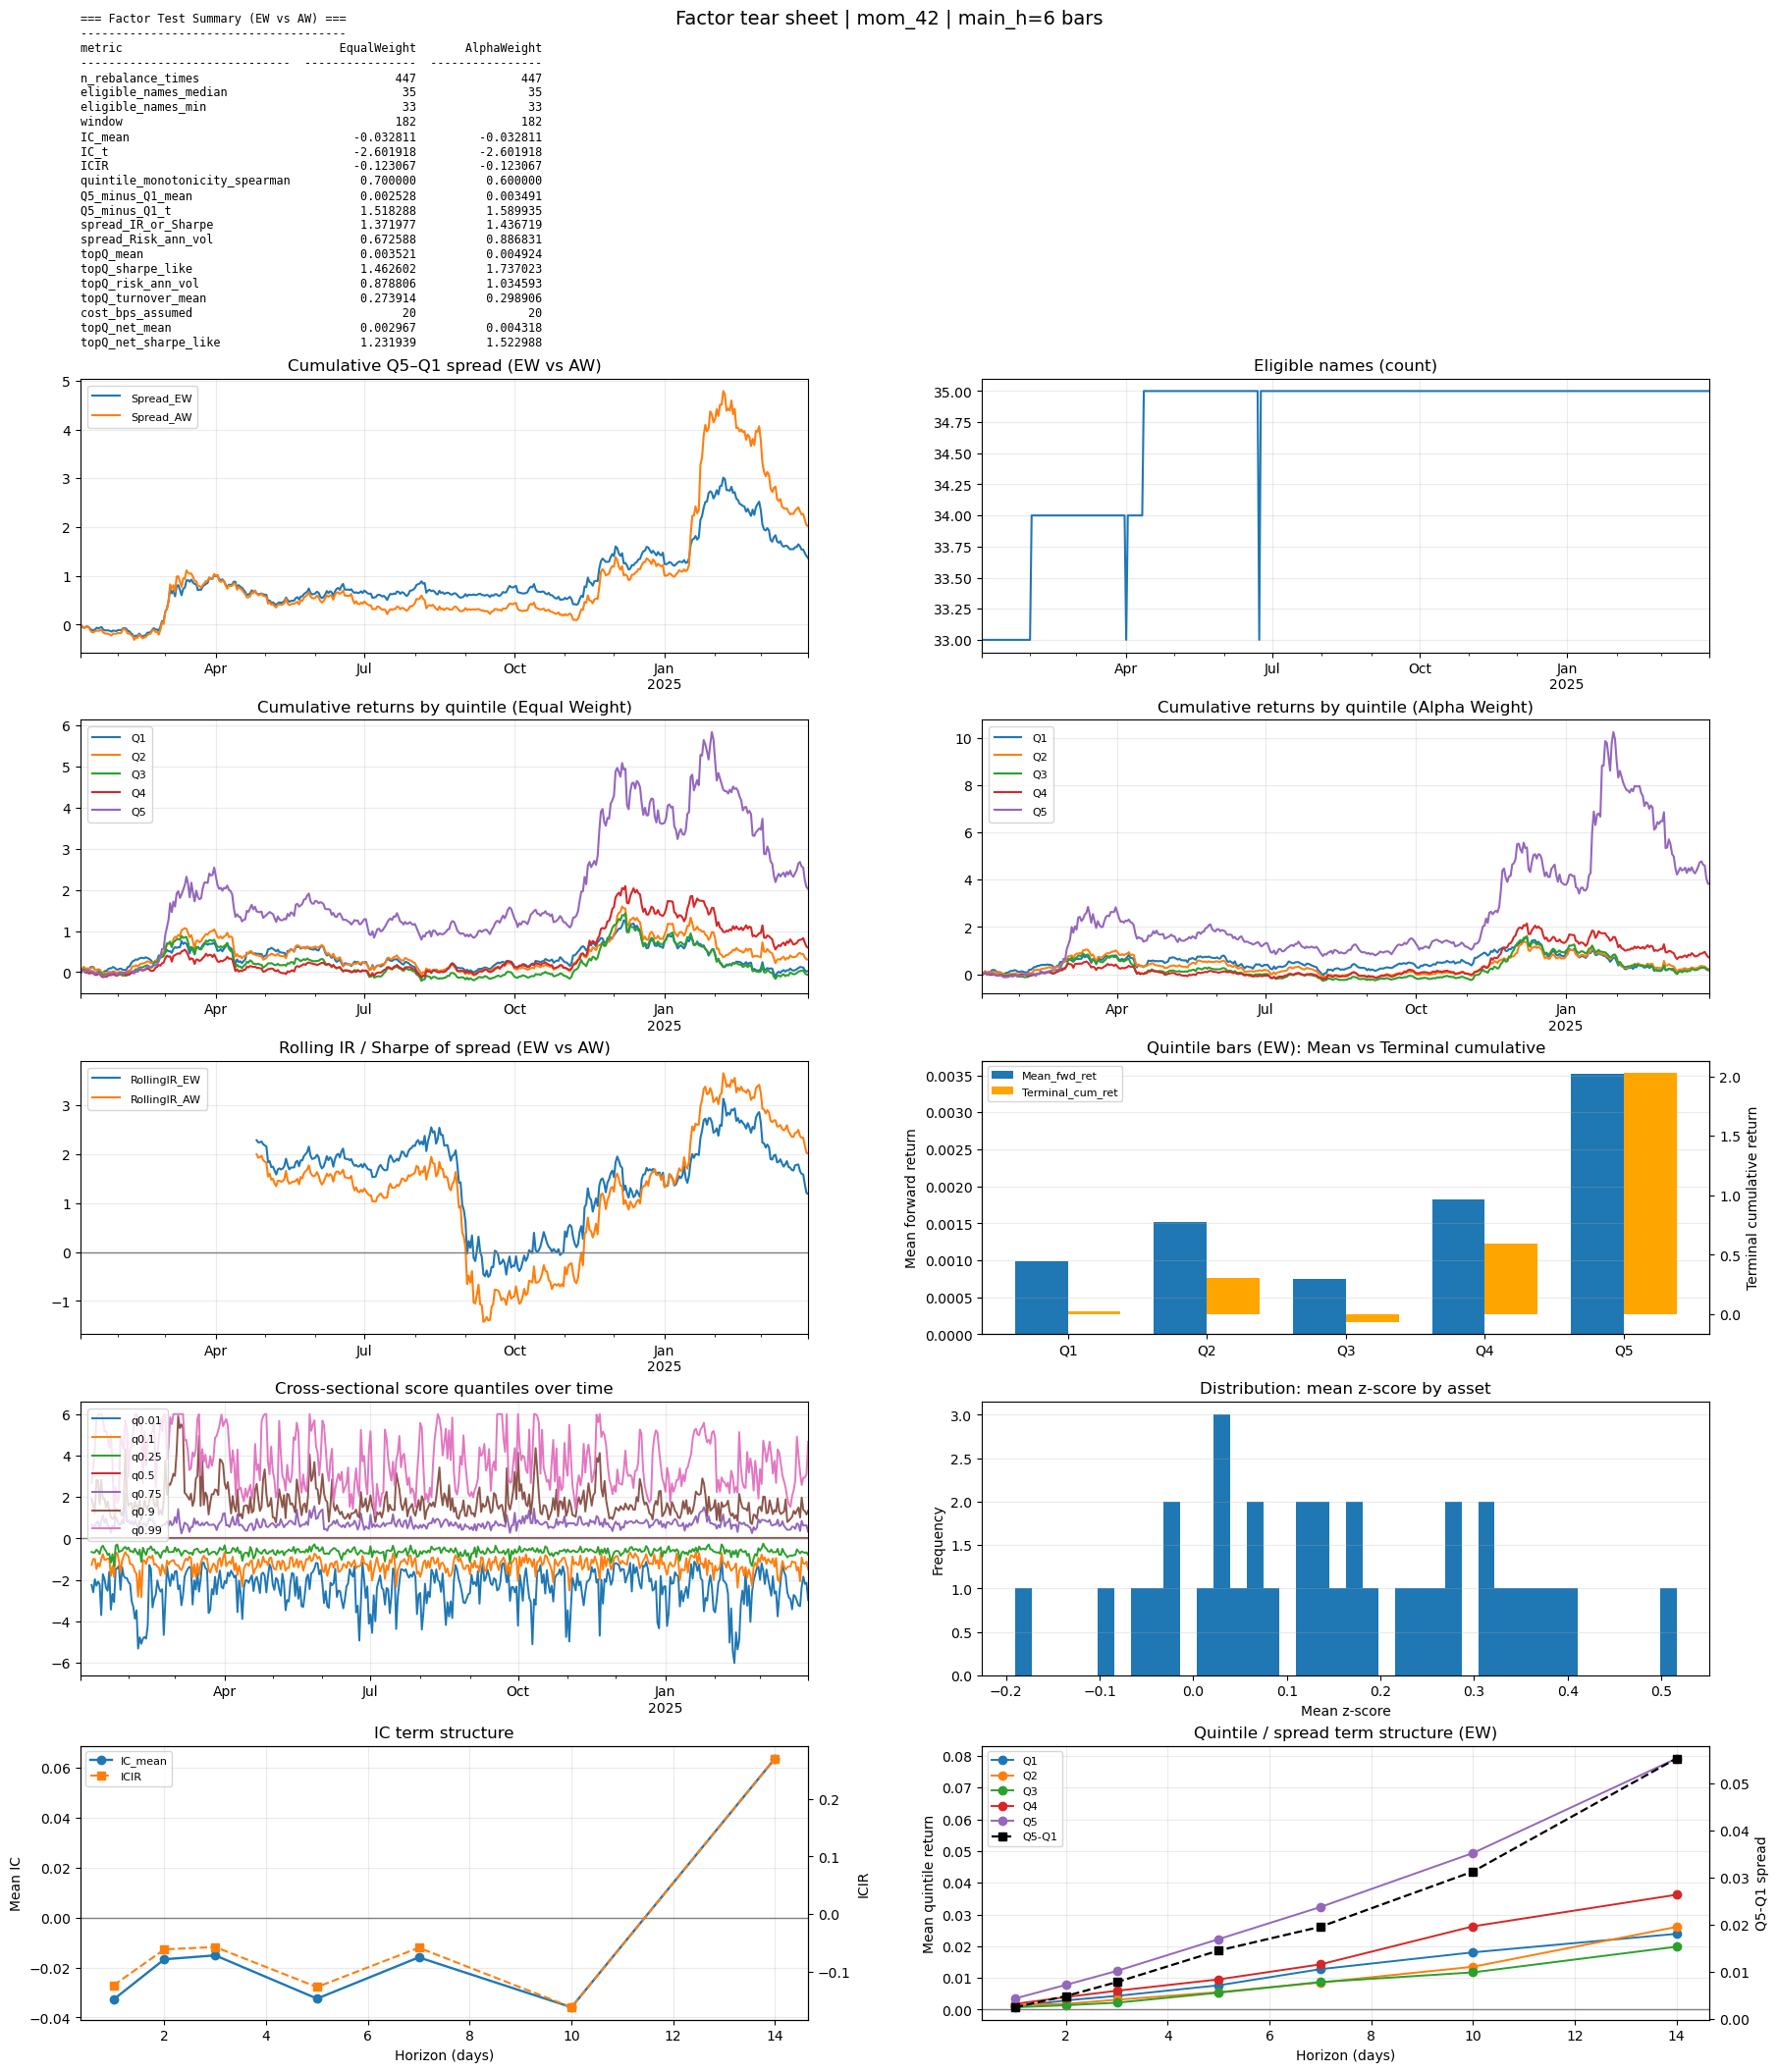

In [123]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"
# FOLDER = "/Users/adheerchauhan/Library/Mobile Documents/com~apple~CloudDocs/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"
MIN_BARS = 2000

CUT_HOUR = 0
EVERY_N_DAYS = 1

bars_per_day = int(round(24 / BAR_HOURS))   # 6
MAIN_HORIZON_BARS = bars_per_day * EVERY_N_DAYS
LOOKBACK_BARS = 42
COST_BPS = 20.0

# horizon grid for IC term structure / quantile term structure
HORIZON_DAYS_LIST = [1, 2, 3, 5, 7, 10, 14]
HORIZON_BARS_LIST = [d * bars_per_day for d in HORIZON_DAYS_LIST]

# include main horizon in case it is not already in the list
ALL_HORIZON_BARS = sorted(set(HORIZON_BARS_LIST + [MAIN_HORIZON_BARS]))


# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# factor
factor_col = f"mom_{LOOKBACK_BARS}"
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=factor_col)

# forward returns for all horizons
for h in ALL_HORIZON_BARS:
    log_col = f"fwd_{h}"
    simple_col = f"fwd_{h}_simple"

    df = add_forward_log_return(df, horizon_bars=h, out_col=log_col)
    df[simple_col] = np.exp(df[log_col]) - 1.0

# rebalance timestamps
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)

# rebalance panel
df_reb = restrict_to_times(df, times)

# evaluator input
df_eval = df_reb.rename(columns={"altname": "asset"}).copy()
df_eval["fwd_ret"] = df_eval[f"fwd_{MAIN_HORIZON_BARS}_simple"]

bars_per_year = 365.0 / EVERY_N_DAYS

# ---- Core tear-sheet evaluation ----
out = evaluate_factor_core(
    df_eval,
    factor_col=factor_col,
    ret_col="fwd_ret",
    eligible_col=None,
    n_q=5,
    min_names=20,
    bars_per_year=bars_per_year,
    rolling_years=0.5,
)

# ---- IC term structure ----
ic_ts = ic_term_structure(
    df=df_eval,
    factor_col=factor_col,
    horizon_bars_list=HORIZON_BARS_LIST,
    bar_hours=BAR_HOURS,
    decision_every_n_days=EVERY_N_DAYS,
    non_overlapping=True,
)

# ---- Optional: quantile / monotonicity term structure ----
qts_ew = quantile_term_structure(
    df=df_eval,
    factor_col=factor_col,
    horizon_bars_list=HORIZON_BARS_LIST,
    bar_hours=BAR_HOURS,
    weight_mode="ew",
    n_q=5,
    min_names=20,
)

qts_aw = quantile_term_structure(
    df=df_eval,
    factor_col=factor_col,
    horizon_bars_list=HORIZON_BARS_LIST,
    bar_hours=BAR_HOURS,
    weight_mode="aw",
    n_q=5,
    min_names=20,
)

# ---- Summary table ----
stats_ew = factor_summary_stats(
    out,
    ann_factor=out["bars_per_year"],
    cost_bps_assumed=COST_BPS,
    use_quantile_returns="ew",
)

stats_aw = factor_summary_stats(
    out,
    ann_factor=out["bars_per_year"],
    cost_bps_assumed=COST_BPS,
    use_quantile_returns="aw",
)

# tbl = factor_summary_table(stats_ew, stats_aw)
# print_factor_summary_table(tbl, title="=== Factor Test Summary (EW vs AW) ===")

# ---- Plot ----
plot_factor_tearsheet_grid(
    out,
    title=f"Factor tear sheet | {factor_col} | main_h={MAIN_HORIZON_BARS} bars",
    ic_ts=ic_ts,
    qts_ew=qts_ew,
    summary_table=tbl,
    summary_title="=== Factor Test Summary (EW vs AW) ===",
)

# # ---- Optional prints ----
# print("\nIC term structure")
# print(ic_ts)

# print("\nQuantile term structure (EW)")
# print(qts_ew[["Q1", "Q2", "Q3", "Q4", "Q5", "Q5_minus_Q1", "monotonicity_spearman"]])

# print("\nQuantile term structure (AW)")
# print(qts_aw[["Q1", "Q2", "Q3", "Q4", "Q5", "Q5_minus_Q1", "monotonicity_spearman"]])

In [75]:
ic_series = ic_time_series(out['work'], score_col='z', ret_col='fwd_12_simple', min_names=15, method='spearman')

In [83]:
ic_series.median()

-0.017850776674306085

In [81]:
ic_series.mean()

-0.020625120227358306

In [93]:
n_q = 5
min_names = 15
cols = ["time", "asset", factor_col] + [f"fwd_{h}_simple" for h in HORIZON_BARS_LIST]
work = out['work'][cols].copy()
work = add_cs_zscore(work, factor_col=factor_col, out_col="z")
work = assign_quantiles(work, score_col="z", n_q=n_q, min_names=min_names, out_col="q")

In [101]:
q_col = 'q'
ret_col = 'fwd_12_simple'
out = (
    work.dropna(subset=[q_col, ret_col])
      .groupby(["time", q_col])[ret_col]
      .mean()
      .unstack(q_col)
      .reindex(columns=range(1, n_q + 1))
      .sort_index()
)
out.columns = [f"Q{int(c)}" for c in out.columns]

In [103]:
out.head()

,Q1,Q2,Q3,Q4,Q5
time,,,,,
2024-01-09 00:00:00+00:00,0.103908,0.054102,0.032066,0.025276,0.033490
2024-01-10 00:00:00+00:00,0.130592,0.146208,0.136548,0.052153,0.072418
2024-01-11 00:00:00+00:00,-0.022021,0.046373,-0.037572,-0.025971,-0.056136
2024-01-12 00:00:00+00:00,-0.028850,-0.023019,-0.016378,-0.048586,-0.014733
2024-01-13 00:00:00+00:00,-0.001114,-0.016632,-0.011371,-0.025905,0.004832


In [113]:
work.groupby(['q']).agg({'fwd_12_simple': ['mean', 'median']})

fwd_12_simple          
             mean    median
q                          
1.0      0.002913 -0.000903
2.0      0.001832  0.001201
3.0      0.001247 -0.001583
4.0      0.004026  0.000873
5.0      0.007816 -0.003182

In [133]:
out['work'][['z','fwd_12_simple']].dropna().corr(method='spearman')

,z,fwd_12_simple
z,1.000000,-0.004914
fwd_12_simple,-0.004914,1.000000


In [127]:
out['work'].agg({'fwd_12_simple': ['mean', 'median']})

,fwd_12_simple
mean,0.003085
median,-0.000991


In [97]:
work.head(20)

,time,asset,mom_42,fwd_6_simple,fwd_12_simple,fwd_18_simple,fwd_30_simple,fwd_42_simple,fwd_60_simple,fwd_84_simple,z,q
608,2024-01-02 00:00:00+00:00,AAVEUSD,NaN,-0.050688,-0.116007,-0.104647,-0.145267,-0.147504,-0.055938,-0.123666,NaN,NaN
614,2024-01-03 00:00:00+00:00,AAVEUSD,NaN,-0.068806,-0.056840,-0.066268,-0.140422,-0.124921,-0.066358,-0.059922,NaN,NaN
620,2024-01-04 00:00:00+00:00,AAVEUSD,NaN,0.012850,0.002726,-0.033100,-0.035631,0.041959,0.032224,-0.014895,NaN,NaN
626,2024-01-05 00:00:00+00:00,AAVEUSD,NaN,-0.009996,-0.045367,-0.088620,-0.072184,0.054402,-0.045848,-0.070261,NaN,NaN
632,2024-01-06 00:00:00+00:00,AAVEUSD,NaN,-0.035728,-0.079417,-0.038252,0.039126,-0.000097,-0.011359,-0.059126,NaN,NaN
638,2024-01-07 00:00:00+00:00,AAVEUSD,NaN,-0.045308,-0.002618,-0.028091,0.104511,0.067559,0.044100,-0.016009,NaN,NaN
644,2024-01-08 00:00:00+00:00,AAVEUSD,NaN,0.044716,0.018034,0.128770,0.086163,0.046931,0.067180,0.003480,NaN,NaN
650,2024-01-09 00:00:00+00:00,AAVEUSD,-0.159587,-0.025540,0.080456,0.107410,0.070361,0.027963,-0.023521,-0.063800,-0.675072,2.0
656,2024-01-10 00:00:00+00:00,AAVEUSD,-0.133441,0.108774,0.136434,0.066922,0.028385,0.074277,0.003937,-0.080700,-0.087003,3.0
662,2024-01-11 00:00:00+00:00,AAVEUSD,0.041102,0.024946,-0.037746,-0.009343,-0.048585,-0.054564,-0.086892,-0.169952,0.151658,4.0


In [57]:
out['work'].head()

,open,high,low,close,volume,trades,asset,time,log_close,mom_42,fwd_6,fwd_6_simple,fwd_12,fwd_12_simple,fwd_18,fwd_18_simple,fwd_30,fwd_30_simple,fwd_42,fwd_42_simple,fwd_60,fwd_60_simple,fwd_84,fwd_84_simple,fwd_ret,z,q
608,114.23,116.27,113.24,116.20,753.266708,177,AAVEUSD,2024-01-02 00:00:00+00:00,4.755313,NaN,-0.052018,-0.050688,-0.123306,-0.116007,-0.110537,-0.104647,-0.156966,-0.145267,-0.159587,-0.147504,-0.057563,-0.055938,-0.132008,-0.123666,-0.050688,NaN,NaN
614,111.57,112.47,108.97,110.31,2121.856085,444,AAVEUSD,2024-01-03 00:00:00+00:00,4.703295,NaN,-0.071288,-0.068806,-0.058519,-0.056840,-0.068566,-0.066268,-0.151314,-0.140422,-0.133441,-0.124921,-0.068663,-0.066358,-0.061792,-0.059922,-0.068806,NaN,NaN
620,100.59,103.61,100.59,102.72,968.236068,367,AAVEUSD,2024-01-04 00:00:00+00:00,4.632007,NaN,0.012769,0.012850,0.002722,0.002726,-0.033660,-0.033100,-0.036281,-0.035631,0.041102,0.041959,0.031715,0.032224,-0.015007,-0.014895,0.012850,NaN,NaN
626,104.35,105.50,103.76,104.04,1100.807757,293,AAVEUSD,2024-01-05 00:00:00+00:00,4.644775,NaN,-0.010046,-0.009996,-0.046428,-0.045367,-0.092795,-0.088620,-0.074922,-0.072184,0.052974,0.054402,-0.046932,-0.045848,-0.072852,-0.070261,-0.009996,NaN,NaN
632,101.02,103.00,101.02,103.00,796.278676,262,AAVEUSD,2024-01-06 00:00:00+00:00,4.634729,NaN,-0.036382,-0.035728,-0.082749,-0.079417,-0.039003,-0.038252,0.038380,0.039126,-0.000097,-0.000097,-0.011424,-0.011359,-0.060946,-0.059126,-0.035728,NaN,NaN


In [63]:
out['work'].groupby(['q']).agg({'fwd_84_simple': ['mean','median','min','max']})

fwd_84_simple                               
             mean    median       min        max
q                                               
1.0      0.023913 -0.014945 -0.498095   6.164565
2.0      0.026153 -0.012349 -0.486025   5.254987
3.0      0.018525 -0.015650 -0.450920   4.644628
4.0      0.036449 -0.018729 -0.513971  10.334448
5.0      0.079194 -0.014658 -0.540233  12.891892

In [61]:
6*14

84

In [78]:
out['work'].groupby(['asset','q']).size()

asset    q  
AAVEUSD  1.0     92
         2.0     71
         3.0     76
         4.0     96
         5.0    113
ADAUSD   1.0     48
         2.0    112
         3.0    118
         4.0    109
         5.0     61
ALGOUSD  1.0     72
         2.0    118
         3.0    105
         4.0     93
         5.0     60
AVAXUSD  1.0     77
         2.0    129
         3.0     98
         4.0     74
         5.0     70
AXSUSD   1.0     46
         2.0    138
         3.0    140
         4.0     89
         5.0     34
BCHUSD   1.0     58
         2.0    113
         3.0    117
         4.0     83
         5.0     77
BONKUSD  1.0    168
         2.0     66
         3.0     49
         4.0     46
         5.0    119
CRVUSD   1.0    114
         2.0     95
         3.0     86
         4.0     72
         5.0     81
DASHUSD  1.0     47
         2.0    111
         3.0    114
         4.0    126
         5.0     50
DOTUSD   1.0     52
         2.0    114
         3.0    148
         4.0     96
       

In [73]:
out['work'][out['work']['time'] == pd.Timestamp('2024-01-09 00:00:00+00:00')].sort_values('z')

,open,high,low,close,volume,trades,asset,time,log_close,mom_42,fwd_6,fwd_6_simple,fwd_12,fwd_12_simple,fwd_18,fwd_18_simple,fwd_30,fwd_30_simple,fwd_42,fwd_42_simple,fwd_60,fwd_60_simple,fwd_84,fwd_84_simple,fwd_ret,z,q
182689,21.570000,21.570000,21.180000,21.330000,3.331877e+03,406,ZECUSD,2024-01-09 00:00:00+00:00,3.060115,-0.265641,-0.078481,-0.075481,0.044472,0.045476,0.138967,0.149086,0.091766,0.096109,0.102403,0.107829,0.052511,0.053915,0.049393,0.050633,-0.075481,-2.285286,1.0
61176,5.812000,5.891000,5.734000,5.870000,8.414899e+04,759,FILUSD,2024-01-09 00:00:00+00:00,1.769855,-0.255790,-0.066562,-0.064395,0.012696,0.012777,0.096084,0.100852,0.028715,0.029131,0.009832,0.009881,-0.045660,-0.044634,-0.139438,-0.130153,-0.064395,-2.135730,1.0
9416,0.199370,0.199370,0.194240,0.194950,7.936341e+05,334,ALGOUSD,2024-01-09 00:00:00+00:00,-1.635012,-0.203302,-0.047534,-0.046422,0.022419,0.022672,0.037256,0.037958,-0.029569,-0.029136,-0.036035,-0.035394,-0.088042,-0.084278,-0.170684,-0.156912,-0.046422,-1.338795,1.0
29039,0.000013,0.000013,0.000011,0.000012,6.430312e+09,467,BONKUSD,2024-01-09 00:00:00+00:00,-11.311782,-0.198974,0.154851,0.167484,0.278749,0.321475,0.277634,0.320003,0.221572,0.248037,0.105459,0.111220,-0.015826,-0.015702,-0.132924,-0.124468,0.167484,-1.273087,1.0
113546,3.420000,3.420000,3.341000,3.349000,1.041654e+05,220,SNXUSD,2024-01-09 00:00:00+00:00,1.208662,-0.197680,-0.008697,-0.008659,0.147946,0.159451,0.162773,0.176769,0.117086,0.124216,0.056876,0.058525,0.006548,0.006569,-0.037109,-0.036429,-0.008659,-1.253441,1.0
143742,6.231000,6.244000,6.138000,6.244000,9.655322e+03,240,UNIUSD,2024-01-09 00:00:00+00:00,1.831621,-0.197316,-0.036700,-0.036035,0.050132,0.051409,0.088971,0.093049,0.061943,0.063901,0.064649,0.066784,0.009881,0.009930,-0.020386,-0.020179,-0.036035,-1.247917,1.0
97123,0.000001,0.000001,0.000001,0.000001,3.963086e+10,91,PEPEUSD,2024-01-09 00:00:00+00:00,-13.639878,-0.166538,0.004186,0.004195,0.108041,0.114094,0.137717,0.147651,0.041895,0.042785,0.010847,0.010906,-0.044604,-0.043624,-0.113597,-0.107383,0.004195,-0.780603,1.0
650,99.730000,99.740000,97.890000,99.060000,6.406395e+02,223,AAVEUSD,2024-01-09 00:00:00+00:00,4.595726,-0.159587,-0.025872,-0.025540,0.077383,0.080456,0.102024,0.107410,0.067996,0.070361,0.027579,0.027963,-0.023802,-0.023521,-0.065926,-0.063800,-0.025540,-0.675072,2.0
38116,28.231000,28.489000,27.850000,28.444000,1.379082e+02,81,DASHUSD,2024-01-09 00:00:00+00:00,3.347937,-0.157800,-0.039367,-0.038602,0.033057,0.033610,0.051091,0.052419,0.040479,0.041309,0.025478,0.025805,-0.020961,-0.020743,-0.015840,-0.015715,-0.038602,-0.647943,2.0
18616,7.906000,7.971000,7.830000,7.946000,4.139415e+03,69,AXSUSD,2024-01-09 00:00:00+00:00,2.072669,-0.153035,-0.060302,-0.058520,0.032562,0.033098,0.072327,0.075006,0.029757,0.030204,-0.009102,-0.009061,-0.047683,-0.046564,-0.071865,-0.069343,-0.058520,-0.575597,2.0


In [ ]:
out['work'][out['work']['time'] == pd.Timestamp('2024-01-09 00:00:00+00:00')].sort_values('z')

In [70]:
out['work'].head(50)

,open,high,low,close,volume,trades,asset,time,log_close,fwd_6,mom_42,fwd_ret,z,q
608,114.23,116.27,113.24,116.20,753.266708,177,AAVEUSD,2024-01-02 00:00:00+00:00,4.755313,-0.052018,NaN,-0.050688,NaN,NaN
614,111.57,112.47,108.97,110.31,2121.856085,444,AAVEUSD,2024-01-03 00:00:00+00:00,4.703295,-0.071288,NaN,-0.068806,NaN,NaN
620,100.59,103.61,100.59,102.72,968.236068,367,AAVEUSD,2024-01-04 00:00:00+00:00,4.632007,0.012769,NaN,0.012850,NaN,NaN
626,104.35,105.50,103.76,104.04,1100.807757,293,AAVEUSD,2024-01-05 00:00:00+00:00,4.644775,-0.010046,NaN,-0.009996,NaN,NaN
632,101.02,103.00,101.02,103.00,796.278676,262,AAVEUSD,2024-01-06 00:00:00+00:00,4.634729,-0.036382,NaN,-0.035728,NaN,NaN
638,100.14,100.33,98.18,99.32,415.878336,194,AAVEUSD,2024-01-07 00:00:00+00:00,4.598347,-0.046367,NaN,-0.045308,NaN,NaN
644,98.50,98.57,93.77,94.82,709.368651,297,AAVEUSD,2024-01-08 00:00:00+00:00,4.551980,0.043745,NaN,0.044716,NaN,NaN
650,99.73,99.74,97.89,99.06,640.639515,223,AAVEUSD,2024-01-09 00:00:00+00:00,4.595726,-0.025872,-0.159587,-0.025540,-0.675072,2.0
656,94.29,96.93,92.52,96.53,1174.688771,537,AAVEUSD,2024-01-10 00:00:00+00:00,4.569854,0.103255,-0.133441,0.108774,-0.087003,3.0
662,103.61,110.19,101.67,107.03,7757.401479,1725,AAVEUSD,2024-01-11 00:00:00+00:00,4.673109,0.024640,0.041102,0.024946,0.151658,4.0


=== Factor Test Summary (EW vs AW) ===
--------------------------------------
metric                               EqualWeight       AlphaWeight
------------------------------  ----------------  ----------------
n_rebalance_times                            447               447
eligible_names_median                         35                35
eligible_names_min                            33                33
window                                        30                30
IC_mean                                -0.032811         -0.032811
IC_t                                   -2.601918         -2.601918
ICIR                                   -0.123067         -0.123067
quintile_monotonicity_spearman          0.700000          0.600000
Q5_minus_Q1_mean                        0.002528          0.003491
Q5_minus_Q1_t                           1.518288          1.589935
spread_IR_or_Sharpe                     1.371977          1.436719
spread_Risk_ann_vol                     0.672588   

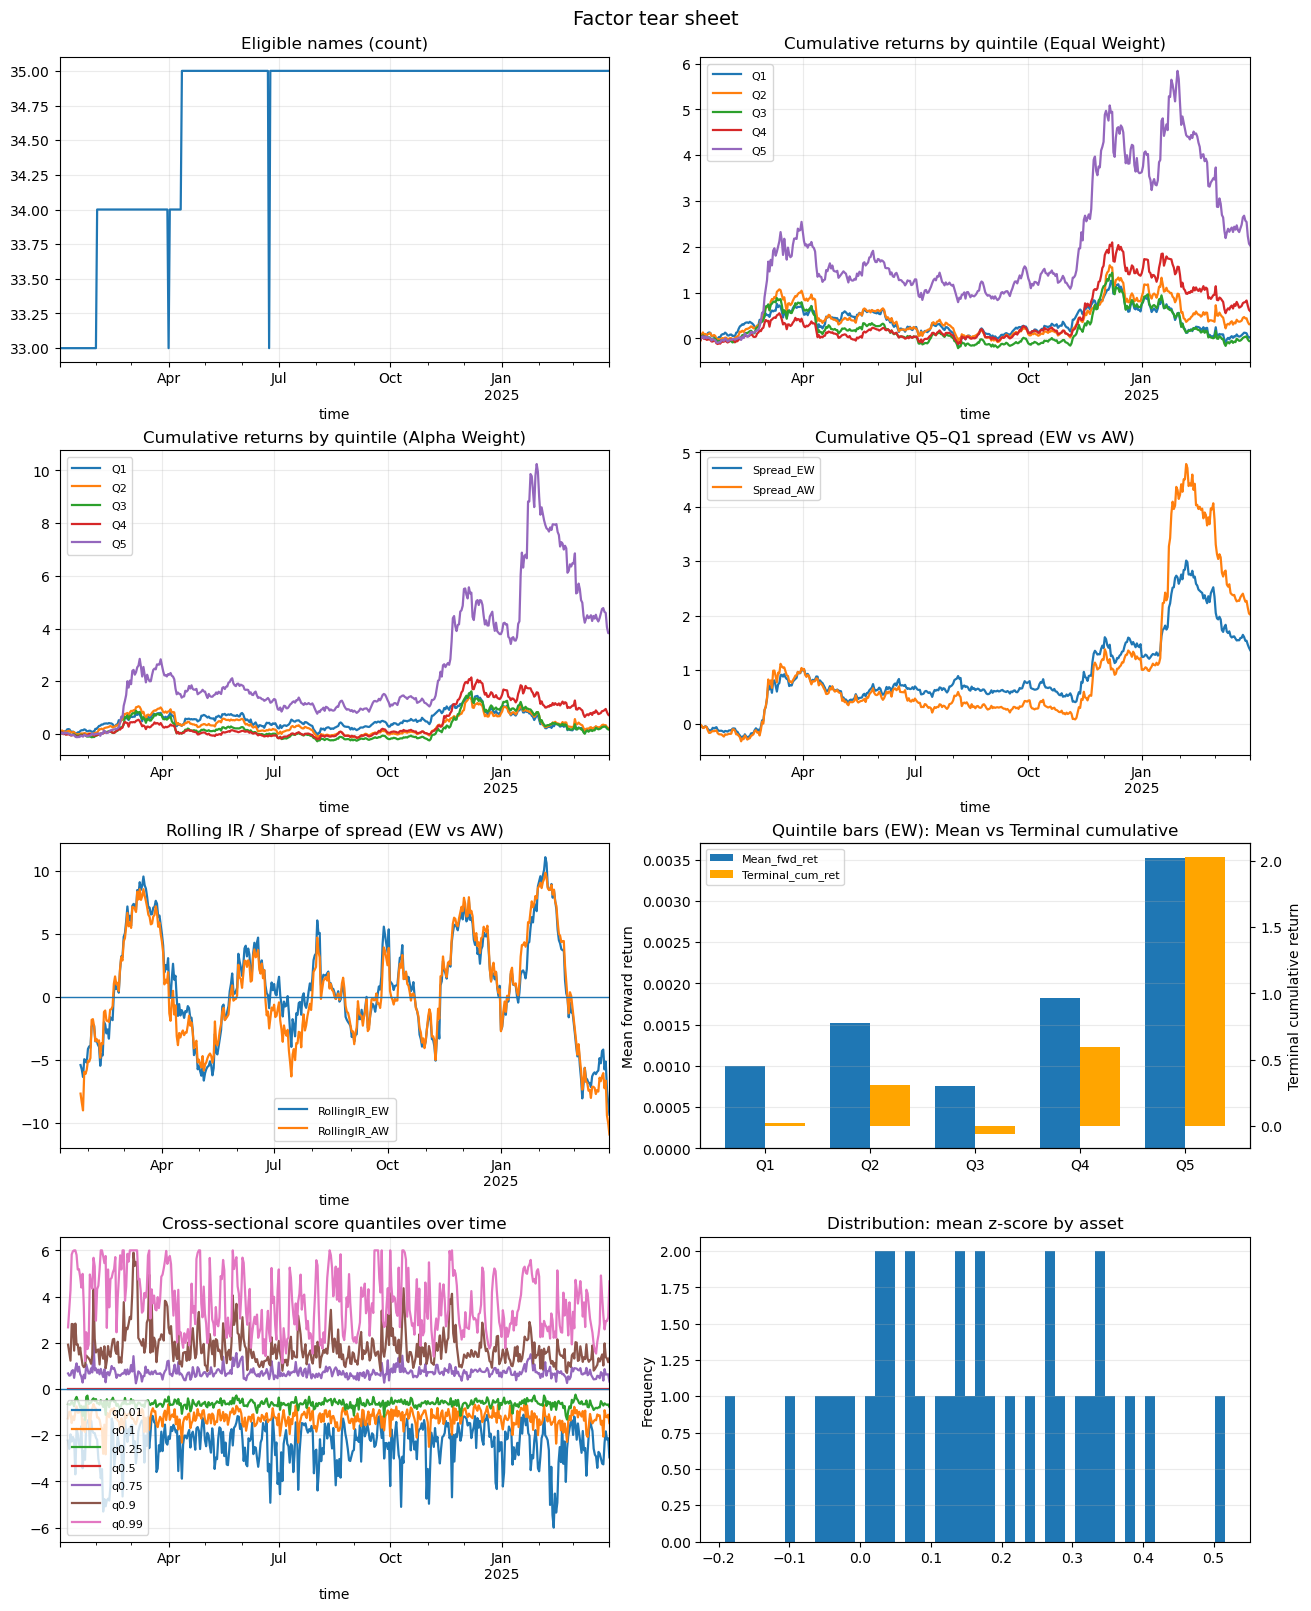

In [52]:
# 0) Adapt your df (altname -> asset, mom_42 -> factor, fwd_6 -> fwd_ret)
df_eval = df_reb.rename(columns={"altname": "asset", "fwd_6_simple": "fwd_ret"}).copy()

bars_per_year = 365.0 / EVERY_N_DAYS   # daily=365, every 2 days=182.5, etc.

# 1) Evaluate core (from earlier)
out = evaluate_factor_core(
    df_eval,
    factor_col="mom_42",
    ret_col="fwd_ret",
    eligible_col=None,   # or None if already filtered
    n_q=5,
    min_names=20,
    bars_per_year=bars_per_year,       # if you're using 4h bars
    rolling_years=0.05
)

# 2) Summary stats (EW version shown; also compute AW if you want)
stats_ew = factor_summary_stats(out, ann_factor=out["bars_per_year"], cost_bps_assumed=20.0, use_quantile_returns="ew")
stats_aw = factor_summary_stats(out, ann_factor=out["bars_per_year"], cost_bps_assumed=20.0, use_quantile_returns="aw")
tbl = factor_summary_table(stats_ew, stats_aw)
print_factor_summary_table(tbl, title="=== Factor Test Summary (EW vs AW) ===")

plot_factor_tearsheet_grid(out, title="Factor tear sheet")

In [54]:
# Spread should equal Q5 - Q1 (EW)
spread_from_qret = out["qret_ew"]["Q5"] - out["qret_ew"]["Q1"]
print("max |spread_ew - (Q5-Q1)|:",
      (out["spread_ew"] - spread_from_qret).abs().max())

max |spread_ew - (Q5-Q1)|: 0.0


In [56]:
cum_q = (1 + out["qret_ew"].fillna(0)).cumprod() - 1
terminal_from_curves = cum_q.iloc[-1]
terminal_from_fn = terminal_cum_returns(out["qret_ew"])

print(pd.concat([terminal_from_curves.rename("from_curves"),
                 terminal_from_fn.rename("from_terminal_fn")], axis=1))

    from_curves  from_terminal_fn
Q1     0.023269          0.023269
Q2     0.306925          0.306925
Q3    -0.063780         -0.063780
Q4     0.594284          0.594284
Q5     2.028190          2.028190


In [64]:
# H = 6  # your HORIZON_BARS
# chk = df_reb.rename(columns={"altname": "asset"}).sort_values(["asset", "time"]).copy()

H_steps = 1  # since df_reb is daily
chk["fwd_ret_check"] = chk.groupby("asset")["close"].shift(-H_steps) / chk["close"] - 1.0

# forward simple return from price (same definition as exp(log_ret)-1)
chk["fwd_ret_check"] = chk.groupby("asset")["close"].shift(-H) / chk["close"] - 1.0

# compare to your stored fwd_ret
chk2 = chk.merge(df_eval[["time","asset","fwd_ret"]], on=["time","asset"], how="left")

err = (chk2["fwd_ret_check"] - chk2["fwd_ret"]).abs()
print("corr:", chk2[["fwd_ret_check","fwd_ret"]].corr().iloc[0,1])
print("median abs err:", err.median())
print("max abs err:", err.max())

corr: 0.41219367176341154
median abs err: 0.06213207918733488
max abs err: 3.5854545454545454


In [60]:
q_counts = out["work"].dropna(subset=["q"]).groupby(["time","q"])["asset"].nunique().unstack()
print(q_counts.describe().T)

     count      mean       std  min  25%  50%  75%  max
q                                                      
1.0  448.0  7.000000  0.000000  7.0  7.0  7.0  7.0  7.0
2.0  448.0  6.926339  0.261510  6.0  7.0  7.0  7.0  7.0
3.0  448.0  6.845982  0.361369  6.0  7.0  7.0  7.0  7.0
4.0  448.0  6.926339  0.261510  6.0  7.0  7.0  7.0  7.0
5.0  448.0  7.000000  0.000000  7.0  7.0  7.0  7.0  7.0


In [62]:
ic = ic_time_series(out["work"], score_col="z", ret_col="fwd_ret", min_names=20)
spread = out["spread_ew"]
print(pd.concat([ic, spread], axis=1).corr())
print("share same sign:", (np.sign(ic) == np.sign(spread)).mean())

                IC  Q5-Q1_EW
IC        1.000000  0.748675
Q5-Q1_EW  0.748675  1.000000


ValueError: Can only compare identically-labeled Series objects

In [ ]:
out.keys()

In [ ]:
out["window"]

In [ ]:
out["bars_per_year"]

### Time Series Momentum (7 Day - 42 Bars)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 1             # try 1, then 2, then 3

HORIZON_BARS = 6             # 24h horizon (6 * 4h)
LOOKBACK_BARS = 42           # 7d momentum (7 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 7d (42 bars) | Horizon 24h (6 bars) | Daily rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_42",
    fwd_col="fwd_6",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 2             # try 1, then 2, then 3

HORIZON_BARS = 12            # 48h horizon (12 * 4h)
LOOKBACK_BARS = 42           # 14d momentum (14 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 7d (42 bars) | Horizon 48h (12 bars) | 2-Day rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_42",
    fwd_col="fwd_12",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 3             # try 1, then 2, then 3

HORIZON_BARS = 18            # 72h horizon (18 * 4h)
LOOKBACK_BARS = 42           # 14d momentum (14 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 7d (42 bars) | Horizon 72h (18 bars) | 3-Day rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_42",
    fwd_col="fwd_18",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

### Time Series Momentum (14 Day - 84 Bars)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 1             # try 1, then 2, then 3

HORIZON_BARS = 6             # 24h horizon (6 * 4h)
LOOKBACK_BARS = 84           # 14d momentum (14 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 14d (84 bars) | Horizon 24h (6 bars) | Daily rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_84",
    fwd_col="fwd_6",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 2             # try 1, then 2, then 3

HORIZON_BARS = 12            # 48h horizon (12 * 4h)
LOOKBACK_BARS = 84           # 14d momentum (14 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 14d (84 bars) | Horizon 48h (12 bars) | 2-Day rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_84",
    fwd_col="fwd_12",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 3             # try 1, then 2, then 3

HORIZON_BARS = 18            # 72h horizon (18 * 4h)
LOOKBACK_BARS = 84           # 14d momentum (14 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 14d (84 bars) | Horizon 72h (18 bars) | 3-Day rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_84",
    fwd_col="fwd_18",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

### Time Series Momentum (30 Day - 180 Bars)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 1             # try 1, then 2, then 3

HORIZON_BARS = 6             # 24h horizon (6 * 4h)
LOOKBACK_BARS = 180          # 30d momentum (30 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 30d (180 bars) | Horizon 24h (6 bars) | Daily rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_180",
    fwd_col="fwd_6",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 2             # try 1, then 2, then 3

HORIZON_BARS = 12            # 48h horizon (12 * 4h)
LOOKBACK_BARS = 180          # 30d momentum (30 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 30d (180 bars) | Horizon 48h (12 bars) | 2-Day rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_180",
    fwd_col="fwd_12",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 3             # try 1, then 2, then 3

HORIZON_BARS = 18            # 72h horizon (18 * 4h)
LOOKBACK_BARS = 180          # 30d momentum (30 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 30d (180 bars) | Horizon 72h (18 bars) | 3-Day rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_180",
    fwd_col="fwd_18",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

### Time Series Momentum (60 Day - 360 Bars)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 1             # try 1, then 2, then 3

HORIZON_BARS = 6             # 24h horizon (6 * 4h)
LOOKBACK_BARS = 360          # 60d momentum (60 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 60d (360 bars) | Horizon 24h (6 bars) | Daily rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_360",
    fwd_col="fwd_6",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 2             # try 1, then 2, then 3

HORIZON_BARS = 12            # 48h horizon (12 * 4h)
LOOKBACK_BARS = 360          # 60d momentum (60 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 60d (360 bars) | Horizon 48h (12 bars) | 2-Day rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_360",
    fwd_col="fwd_12",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 3             # try 1, then 2, then 3

HORIZON_BARS = 18            # 72h horizon (18 * 4h)
LOOKBACK_BARS = 360          # 60d momentum (60 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 60d (360 bars) | Horizon 72h (18 bars) | 3-Day rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_360",
    fwd_col="fwd_18",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)

In [ ]:
# ---- Config ----
FOLDER = "/Users/adheerchauhan/Documents/crypto_research_data/kraken_master_240_parquet"

IS_END = "2025-04-01"        # exclusive (15 months IS)
MIN_BARS = 2000              # Tier A discovery filter (~1 year+)

CUT_HOUR = 0                 # daily rebalance cut (UTC)
EVERY_N_DAYS = 3             # try 1, then 2, then 3

HORIZON_BARS = 18            # 72h horizon (18 * 4h)
LOOKBACK_BARS = 360          # 60d momentum (60 * 6 bars/day)

COST_BPS = 20.0              # placeholder; set 0 for now if you want gross-only

# ---- Build IS long ----
df = load_long_bar_end(FOLDER)
df = filter_in_sample(df, IS_END)
df = filter_min_bars(df, MIN_BARS)
df = add_log_close(df)

# forward return + factor
df = add_forward_log_return(df, horizon_bars=HORIZON_BARS, out_col=f"fwd_{HORIZON_BARS}")
df = add_momentum(df, lookback_bars=LOOKBACK_BARS, out_col=f"mom_{LOOKBACK_BARS}")

# restrict to rebalance times
times = rebalance_times(df, cut_hour_utc=CUT_HOUR, every_n_days=EVERY_N_DAYS)
df_reb = restrict_to_times(df, times)

factor_name = "Momentum 60d (360 bars) | Horizon 72h (18 bars) | 3-Day rebalance"

card = factor_card_clean(
    df_reb=df_reb,
    factor_col="mom_360",
    fwd_col="fwd_18",
    factor_name=factor_name,
    min_names=25,
    q=5,
    top_q=5,
    cost_bps=20.0,  # set 0.0 if you want gross-only initially
)

print_factor_card(card)
plot_factor_card(card, rolling_window=63)